In [1]:
from math import exp, factorial
import numpy as np
import matplotlib.pyplot as plt

In [2]:
maxcars = 20
#possible states (cars at loc1, cars at loc2)
states = [(i, j) for i in range(maxcars + 1) for j in range(maxcars + 1)]

DISCOUNT = 0.9
#possible actions: move cars overnight
ACTIONS = list(range(-5, 6))

#poisson parameters
RENT_L1, RENT_L2 = 3, 4
RET_L1, RET_L2 = 3, 2
CAP = 10

In [3]:
#poisson distribution
def poisson_probs(lam, cap=CAP):
    probs = [0.0] * (cap + 1)
    base = exp(-lam)
    for k in range(cap):
        probs[k] = (lam ** k / factorial(k)) * base
    # dump leftover probability mass into the last bucket
    probs[cap] = 1 - sum(probs[:-1])
    return probs

#poisson tables
poisson = {
    RENT_L1: poisson_probs(RENT_L1),
    RENT_L2: poisson_probs(RENT_L2),
    RET_L1: poisson_probs(RET_L1),
    RET_L2: poisson_probs(RET_L2),
}

In [4]:
#MDP transitions
mdp = {s: {} for s in states}

for s in states:
    for a in ACTIONS:
        # action not possible (trying to move more cars than we have)
        if a > s[0] or -a > s[1]:
            mdp[s][a] = [(0.0, s, 0.0)]
            continue

        # apply action and clamp to max capacity
        cars = [min(maxcars, s[0] - a), min(maxcars, s[1] + a)]
        if cars[0] < 0 or cars[1] < 0:
            continue

        buffer = {}

        # loop over all possible rentals and returns
        for r1 in range(CAP + 1):
            for r2 in range(CAP + 1):
                real_r1 = min(r1, cars[0])
                real_r2 = min(r2, cars[1])

                for b1 in range(CAP + 1):
                    for b2 in range(CAP + 1):
                        # compute next state after rentals + returns
                        nxt = (
                            min(maxcars, max(0, cars[0] - real_r1 + b1)),
                            min(maxcars, max(0, cars[1] - real_r2 + b2))
                        )

                        # probability of this whole combo happening
                        prob = (
                            poisson[RENT_L1][r1] *
                            poisson[RENT_L2][r2] *
                            poisson[RET_L1][b1] *
                            poisson[RET_L2][b2]
                        )

                        # reward = rentals profit - moving cost
                        reward = 10 * (real_r1 + real_r2) - 2 * abs(a)

                        if nxt not in buffer:
                            buffer[nxt] = [0.0, 0.0]

                        buffer[nxt][0] += prob
                        buffer[nxt][1] += prob * reward

        # convert buffer into transition list
        transitions = []
        for nxt_state, (p_sum, r_sum) in buffer.items():
            if p_sum > 0:
                transitions.append((p_sum, nxt_state, r_sum / p_sum))

        mdp[s][a] = transitions

In [5]:
def not_converged(old_v, new_v, eps):
    return max(abs(new_v[s] - old_v[s]) for s in old_v) > eps

In [6]:
# policy iteration
V = {s: 10.0 for s in states}     # value function
V_new = {s: 0.0 for s in states}

policy = {s: 0 for s in states}  # current policy
policy_old = {s: 5 for s in states}

EPS = 1e-4
iterations = 0

while policy != policy_old:
    iterations += 1
    policy_old = policy.copy()

    # policy evaluation step
    for s in states:
        V[s] = 10.0
        V_new[s] = 0.0

    while not_converged(V, V_new, EPS):
        V = V_new.copy()
        for s in states:
            value = 0.0
            for p, nxt, r in mdp[s][policy[s]]:
                value += p * (r + DISCOUNT * V[nxt])
            V_new[s] = value

    # policy improvement step
    for s in states:
        best_action = None
        best_val = -float("inf")

        for a in ACTIONS:
            val = 0.0
            for p, nxt, r in mdp[s][a]:
                val += p * (r + DISCOUNT * V_new[nxt])

            if val > best_val:
                best_val = val
                best_action = a

        policy[s] = best_action

print("Iterations:", iterations)


Iterations: 5


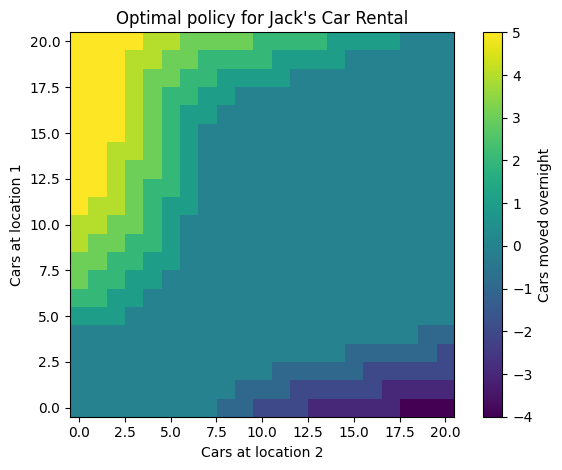

In [7]:
# plot the final policy
policy_grid = np.zeros((MAX_CARS + 1, MAX_CARS + 1))
for (i, j), a in policy.items():
    policy_grid[i, j] = a

plt.imshow(policy_grid, origin="lower", cmap="viridis")
plt.colorbar(label="Cars moved overnight")
plt.xlabel("Cars at location 2")
plt.ylabel("Cars at location 1")
plt.title("Optimal policy for Jack's Car Rental")
plt.tight_layout()
plt.show()

In [8]:
# final value function for the optimal policy
for s in states:
    V[s] = 10.0
    V_new[s] = 0.0

while not_converged(V, V_new, EPS):
    V = V_new.copy()
    for s in states:
        V_new[s] = sum(
            p * (r + DISCOUNT * V[nxt])
            for p, nxt, r in mdp[s][policy[s]]
        )

print(V_new)

{(0, 0): 421.3938273034235, (0, 1): 431.36605041539, (0, 2): 441.2217510013681, (0, 3): 450.8271020002931, (0, 4): 460.05997021766564, (0, 5): 468.8521760533592, (0, 6): 477.1906301323491, (0, 7): 485.0944689047992, (0, 8): 492.9577719172784, (0, 9): 500.4535769063655, (0, 10): 507.8656816960504, (0, 11): 514.9711769873597, (0, 12): 521.7279572565346, (0, 13): 528.3282624811038, (0, 14): 534.7168394810859, (0, 15): 540.8033817783012, (0, 16): 546.6061546870218, (0, 17): 552.1414892011142, (0, 18): 557.5656378884917, (0, 19): 562.7682967078296, (0, 20): 567.7176151079863, (1, 0): 431.2675834570993, (1, 1): 441.2397403637601, (1, 2): 451.0951124289147, (1, 3): 460.6996208576597, (1, 4): 469.9309852891982, (1, 5): 478.72105941188426, (1, 6): 487.0568994542541, (1, 7): 494.9577719172784, (1, 8): 502.4535769063655, (1, 9): 509.8656816960504, (1, 10): 516.9711769873597, (1, 11): 523.7279572565346, (1, 12): 530.3282624811038, (1, 13): 536.7168394810859, (1, 14): 542.8033817783012, (1, 15): 54